# Texture tomography of Al1050 with a basis from the ODF

The same reconstruction as `textomo_adaptive.ipynb`, but the orientation basis comes from the data themselves
instead of from peak segmentation and point-by-point indexing:

1. the data summed over the translations are a bulk measurement of the sample's orientation distribution
   (ODF): data = PF @ w, with w the volume per orientation (the texture operator on a single pixel);
2. the ODF is reconstructed coarse to fine: a uniform (cubochoric) grid of the fundamental zone at 4 deg,
   then refinements that halve the spacing around the strongest orientations (99 % of the weight), down
   to 0.5 deg. The sample is 15 % deformed, so its ODF is broad: a 0.25 deg level would hold ~10^7
   candidates;
3. the basis is the support of the finest level (weight above `SUPPORT_REL` x the maximum), thinned to a
   minimum distance; the reconstruction then runs as in `textomo_adaptive.ipynb`.

The ODF is reconstructed in the operator's frame, so the basis needs no rotation by `OMEGA_OFFSET_DEG`
(the indexed basis does). `diffractom.odf_basis` (diffractom branch `odf-basis`).

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "integration" / "frame_loader.py").is_file())
sys.path.insert(0, str(REPO))

import os
import time

import h5py
import numpy as np
import matplotlib.pyplot as plt
import pyopencl as cl
from orix import plot as orix_plot
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d
from scipy.spatial.transform import Rotation as R
from diffractom import FISTAHuber, Grid, Material, SinglePhaseForwardOperator, estimate_L_power_streamed
from diffractom.operators.single_phase_forward_operator import group_reflections_into_rings
from diffractom import MatrixGrid
from diffractom.odf_basis import basis_from_odf, nearest_misorientation_deg, reconstruct_odf, symmetry_rotations
from integration.frame_loader import OUTPUT_PATH, PROCESS
from integration.integrated_data import IntegratedData

plt.style.use("dark_background")

## Data
The polarization-corrected integration, `I[translation, omega, eta, ring]`: 181 translations,
3003 omega steps over 360.12 deg, 360 eta bins and 14 rings. It is reduced for the
reconstruction:

* **translations**: the 11 scan files overlap, so 30 translation positions were measured
  twice; the pairs are averaged, leaving 151 positions 0.01 mm apart;
* **omega**: the first 3000 frames (exactly one turn, 359.88 deg) are summed in groups of 6,
  giving 500 bins of 0.72 deg;
* **eta and rings** are kept as integrated.

The result is reordered to the operator's `(omega, translation, eta, ring)` and each ring is
scaled to the same total intensity, so that no ring dominates the fit.

In [2]:
data = IntegratedData(OUTPUT_PATH)  # polarization-corrected integration
assert data.polarization_corrected is True
print(data)

N_FRAMES = 3000  # one full turn
OMEGA_BIN = 6    # frames per omega bin

t0 = time.perf_counter()
positions = np.round(data.translations, 4)
unique_positions = np.unique(positions)
n_omega = N_FRAMES // OMEGA_BIN
reduced = np.zeros((len(unique_positions), n_omega, data.n_eta, data.n_rings), dtype=np.float32)
count = np.zeros(len(unique_positions))
for t in range(data.n_translations):
    u = np.searchsorted(unique_positions, positions[t])
    reduced[u] += data.I[t, :N_FRAMES].reshape(n_omega, OMEGA_BIN, data.n_eta, data.n_rings).sum(axis=1)
    count[u] += 1
reduced /= count[:, None, None, None].astype(np.float32)
print(f"{int((count == 2).sum())} translation pairs averaged; reduced in {time.perf_counter() - t0:.0f} s")

arr = np.ascontiguousarray(reduced.transpose(1, 0, 2, 3))  # (N_Omega, My, N_eta, N_theta)
del reduced
ring_sums = arr.sum(axis=(0, 1, 2), dtype=np.float64)
arr *= (ring_sums.sum() / ring_sums).astype(np.float32)
N_Omega, My, N_eta, N_theta = arr.shape
omega_step = float(np.median(np.diff(data.omega_deg)))
print(f"data {arr.shape}, omega range {N_FRAMES * omega_step:.2f} deg")

IntegratedData: /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/scan-0048-0058_integrated_polcorr.json
  array   : (181, 3003, 360, 14)  axes=['translation', 'omega', 'eta', 'q_ring']  float32  (10.96 GB, memmap)
  dty     : 181 steps, -0.75 .. 0.75
  omega   : 3003 steps, 0 .. 360.1 deg
  eta     : 360 bins, range -180..180 deg
  rings   : 14, q_width = 1.2 nm^-1
    [ 0] q =   26.845 nm^-1   hkl: (-1, -1, -1)
    [ 1] q =   30.997 nm^-1   hkl: (-2, 0, 0)
    [ 2] q =   43.837 nm^-1   hkl: (-2, -2, 0)
    [ 3] q =   51.403 nm^-1   hkl: (-3, -1, -1)
    [ 4] q =   53.689 nm^-1   hkl: (-2, -2, -2)
    [ 5] q =   61.995 nm^-1   hkl: (-4, 0, 0)
    [ 6] q =   67.557 nm^-1   hkl: (-3, -3, -1)
    [ 7] q =   69.312 nm^-1   hkl: (-4, -2, 0)
    [ 8] q =   75.928 nm^-1   hkl: (-4, -2, -2)
    [ 9] q =   80.534 nm^-1   hkl: (-3, -3, -3), (-5, -1, -1)
    [10] q =   87.674 nm^-1   hkl: (-4, -4, 0)
    [11] q =   91.692 nm^-1   hkl: (-5, -3, -1)
  

30 translation pairs averaged; reduced in 47 s


data (500, 151, 360, 14), omega range 359.88 deg


## Data weights
Zero weight for

* the eta bins along the rotation axis (pyFAI azimuth within 10 deg of +-90 deg), as for the
  simulated data: peaks there cross the Ewald sphere at grazing angles;
* eta bins that the detector gaps leave (almost) empty: mean intensity below 5% of the
  ring's median. These are many for the outer rings, which run off the detector.

empty eta bins per ring: [34, 88, 27, 32, 24, 19, 15, 17, 18, 19, 83, 132, 144, 0]
22.0% of the data has zero weight


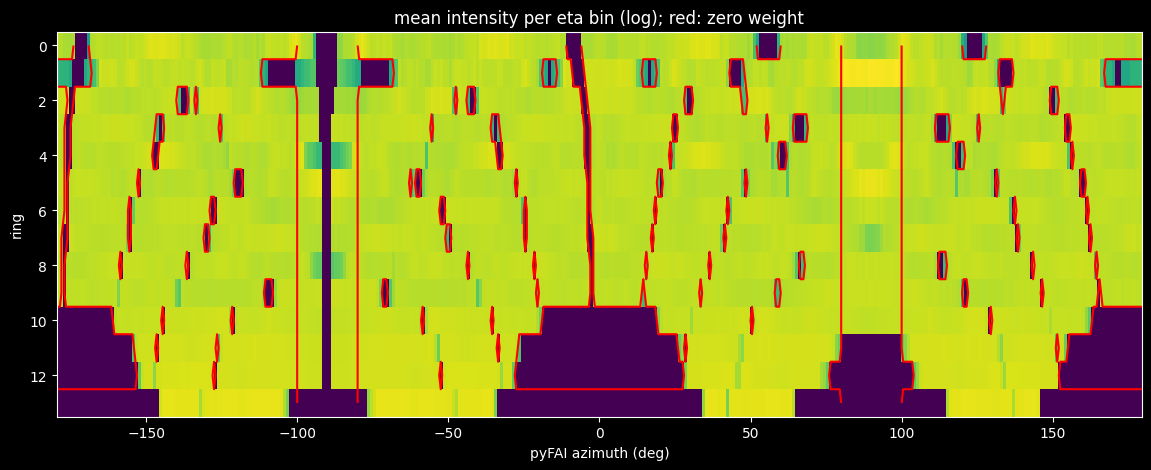

In [3]:
eta = data.eta_deg
weights = np.ones((N_eta, N_theta), dtype=np.float32)  # one weight per (eta bin, ring), for every omega and translation
weights[np.abs(np.abs(eta) - 90) < 10, :] = 0
profile = arr.mean(axis=(0, 1))                                    # (N_eta, N_theta)
empty = profile < 0.05 * np.median(profile, axis=0, keepdims=True)
weights[empty] = 0
print(f"empty eta bins per ring: {empty.sum(axis=0).tolist()}")
print(f"{100 * (weights == 0).mean():.1f}% of the data has zero weight")

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.imshow(np.log10(profile.T + 1e-3), aspect="auto", extent=[eta[0], eta[-1], N_theta - 0.5, -0.5])
ax.contour(eta, np.arange(N_theta), (weights == 0).T, levels=[0.5], colors="r")
ax.set_xlabel("pyFAI azimuth (deg)")
ax.set_ylabel("ring")
ax.set_title("mean intensity per eta bin (log); red: zero weight")
plt.show()

## Geometry
The conventions were determined from the data, not assumed:

* **eta and omega**: the bulk pattern of the data (summed over all translations, which removes all spatial
  information) was compared with the bulk pattern predicted from the point-by-point orientations, for
  eta = 0 along +-y or +-z, both senses of eta and of rotation, and every omega offset (0.72 deg steps).
  Eta = 0 along +y, eta = 90 deg along +z and rotation `angle_range = [0, 359.88]` match with correlation
  0.66, against at most 0.09 for every other convention.
* **omega offset**: `OMEGA_OFFSET_DEG` = 50 deg is subtracted from the rotation angles. This rotates the
  reconstruction frame about the rotation axis so that the sides of the square sample are parallel to the
  grid axes. The basis orientations are rotated with it
  (`Rz(+OMEGA_OFFSET_DEG) @ U`, see the orientation grid below), which reproduces the fit of the unrotated
  geometry.
* **centre of rotation**: the rotation axis is at dty = -0.0324 mm (`rotation_axis_com.npy`, from
  `adaptive_basis/indexing/01_find_rotation_axis.ipynb`), i.e. `cor_offset = +3.24` translation steps. The
  opposite sign fits clearly worse (30 FISTA iterations: relative weighted residual 0.80 against 0.59).
* **field of view**: the sample is a square of about 1 mm side. The reconstruction grid (`Nx` x `Ny` voxels
  of 0.01 mm, set in `cfg`) must cover it: with the omega offset its sides are parallel to the grid axes and
  about 115 voxels suffice; the full translation range is 151 voxels.

The bulk data do not distinguish this geometry from the same one with eta = 90 deg along -z and the
rotation starting at 180 deg: the two fit the data equally well and give the same reconstruction rotated by
180 deg in the sample plane. Which one matches the sample frame of the point-by-point map can be checked by
comparing the reconstructed orientation map with it.

In [4]:
rotation_axis_mm = float(np.load(os.path.join(PROCESS, "al1050_15pct_center_slice", "rotation_axis_com.npy")))
translation_step_mm = float(np.median(np.diff(unique_positions)))

# Rotates the reconstruction frame by OMEGA_OFFSET_DEG about the rotation axis, so the square sample lines up
# with the grid axes. The basis is rotated by Rz(+OMEGA_OFFSET_DEG) to match (see the orientation grid below).
OMEGA_OFFSET_DEG = 50.0

cfg = {
    "energy": 12.398 / data.wavelength_A,  # keV, with the operator's hc = 12.398 keV A
    "Nx": 115,
    "Ny": 115,
    "My": My,
    "N_Omega": N_Omega,
    "N_eta": N_eta,
    "angle_range": [-OMEGA_OFFSET_DEG, N_FRAMES * omega_step - OMEGA_OFFSET_DEG],  # deg, one full turn
    "cor_offset": -rotation_axis_mm / translation_step_mm,  # translation steps
    "eta_angle_range": [0, 360],
    "j_direction_0": [0, -1, 0],
    "k_direction_0": [0, 0, 1],  # rotation axis
    "p_direction_0": [1, 0, 0],  # beam
    "detector_direction_origin": [0, 1, 0],  # eta = 0
    "detector_direction_positive_90": [0, 0, 1],  # eta = 90 deg
}
cfg

{'energy': 34.79693815957518,
 'Nx': 115,
 'Ny': 115,
 'My': 151,
 'N_Omega': 500,
 'N_eta': 360,
 'angle_range': [-50.0, 309.8801198801027],
 'cor_offset': 3.243855634667871,
 'eta_angle_range': [0, 360],
 'j_direction_0': [0, -1, 0],
 'k_direction_0': [0, 0, 1],
 'p_direction_0': [1, 0, 0],
 'detector_direction_origin': [0, 1, 0],
 'detector_direction_positive_90': [0, 0, 1]}

## Material
The unit cell, and every reflection family of every integrated ring. Rings 9 ((333)+(511))
and 12 ((442)+(600)) hold two families with the same two-theta; the operator groups the
reflections into rings and sums their pole figures, each pole weighted equally.

In [5]:
lattice = data.material["lattice_params"]
hkl_list = np.array([hkl for ring in data.rings for hkl in ring["hkl"]])  # all families of every ring
mat = Material.from_lattice_parameters(
    a=lattice["a"], b=lattice["b"], c=lattice["c"],
    alpha=lattice["alpha"], beta=lattice["beta"], gamma=lattice["gamma"],
    symmetry_group="cubic",
    wavelength_A=data.wavelength_A,
    min_two_theta=0.0,
    max_two_theta=0.0,
    hkl_list=hkl_list,
)
rings = group_reflections_into_rings(mat)
ring_two_theta = np.array([mat.reflections["two_theta"][r[0]] for r in rings])
assert len(rings) == N_theta and np.allclose(ring_two_theta, data.two_theta_rad, rtol=1e-4), \
    "material rings do not match the integrated rings"
print(f"{len(mat.reflections)} reflections in {len(rings)} rings")
mat.reflections[["hkl", "multiplicity", "two_theta"]]

16 reflections in 14 rings


array([([-1, -1, -1],  8, 0.15237289), ([-2,  0,  0],  6, 0.17600197),
       ([-2, -2,  0], 12, 0.24922777), ([-3, -1, -1], 24, 0.29253163),
       ([-2, -2, -2],  8, 0.30563931), ([-4,  0,  0],  6, 0.35338573),
       ([-3, -3, -1], 24, 0.38547466), ([-4, -2,  0], 24, 0.39561959),
       ([-4, -2, -2], 24, 0.43395587), ([-3, -3, -3],  8, 0.46074108),
       ([-5, -1, -1], 24, 0.46074108), ([-4, -4,  0], 12, 0.50243462),
       ([-5, -3, -1], 48, 0.52599175), ([-6,  0,  0],  6, 0.53363387),
       ([-4, -4, -2], 24, 0.53363387), ([-6, -2,  0], 24, 0.56326565)],
      dtype={'names': ['hkl', 'multiplicity', 'two_theta'], 'formats': [('<i4', (3,)), '<i4', '<f8'], 'offsets': [0, 12, 24], 'itemsize': 40})

## ODF from the data summed over translations
Each level is a nonnegative least-squares fit of the summed data (same weights as the reconstruction) with
Gaussian kernels of width 0.6 x the spacing; 50 iterations at the first level and between, 200 at the last.

In [6]:
ODF_SPACING_DEG = 4.0   # level 0: uniform grid of the fundamental zone
ODF_LEVELS = 4          # 4, 2, 1, 0.5 deg
KEEP_MASS = 0.99        # refine around the strongest orientations holding this fraction of the weight

ctx = cl.create_some_context(interactive=False)  # one OpenCL context for the ODF and the reconstruction
queue = cl.CommandQueue(ctx)

t0 = time.perf_counter()
levels = reconstruct_odf(cfg, mat, arr.reshape(N_Omega, My, N_eta * N_theta), weights, spacing_deg=ODF_SPACING_DEG,
                         levels=ODF_LEVELS, keep_mass=KEEP_MASS, niter_between=50, max_gb=8.0, ctx=ctx, queue=queue)
odf_time = time.perf_counter() - t0
print(f"ODF in {odf_time:.0f} s")

ODF level 0: spacing 4.000 deg, sigma 2.400 deg, K 11935, PF sparse, 31 s, relative residual 0.5468


  1712 orientations above 0.001 x max (0.9900 of the weight) -> 109568 children -> 46091 after thinning


ODF level 1: spacing 2.000 deg, sigma 1.200 deg, K 46091, PF sparse, 34 s, relative residual 0.4287


  7946 orientations above 0.001 x max (0.9900 of the weight) -> 508544 children -> 226227 after thinning


ODF level 2: spacing 1.000 deg, sigma 0.600 deg, K 226227, PF sparse, 51 s, relative residual 0.3614


  53679 orientations above 0.001 x max (0.9900 of the weight) -> 3435456 children -> 1566103 after thinning


ODF level 3: spacing 0.500 deg, sigma 0.300 deg, K 1566103, PF generated, 1377 s, relative residual 0.3195


ODF in 1590 s


## Orientation grid: the support of the finest ODF level
Orientations above `SUPPORT_REL` x the maximum weight, thinned to `MIN_DISTANCE_DEG` in order of weight.

In [7]:
SUPPORT_REL = 0.03
MIN_DISTANCE_DEG = 0.4
sigma_deg = 0.4  # width of the Gaussian kernel around every basis orientation (as the adaptive basis)

basis = basis_from_odf(levels[-1], mat, rel=SUPPORT_REL, min_distance_deg=MIN_DISTANCE_DEG)
grid = MatrixGrid(basis, np.deg2rad(sigma_deg))  # arrays, no per-orientation objects
K = len(grid.nodes_at_level(0))
print(f"K = {K} orientations, sigma = {sigma_deg} deg")

K = 34845 orientations, sigma = 0.4 deg


## Comparison with the adaptive (indexing) basis
The misorientation from each indexed orientation (rotated into the operator frame) to the closest
orientation of this basis.

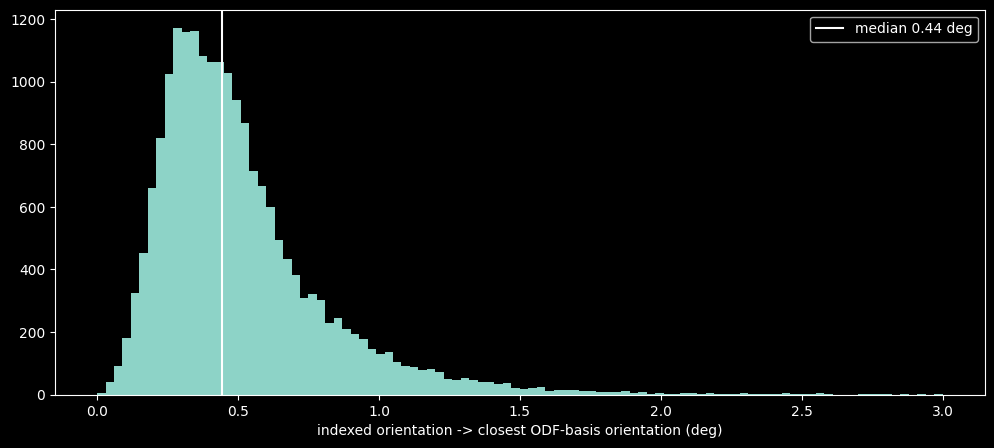

In [8]:
indexed = R.from_euler("z", OMEGA_OFFSET_DEG, degrees=True).as_matrix() @ np.load(os.path.join(REPO, "adaptive_basis", "basis.npy"))
q_ix = R.from_matrix(indexed).as_quat()
q_ix = q_ix[np.random.default_rng(0).choice(len(q_ix), 20000, replace=False)]
mis = nearest_misorientation_deg(q_ix, R.from_matrix(basis).as_quat(), symmetry_rotations(mat))

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.hist(mis, bins=100, range=(0, 3))
ax.axvline(np.median(mis), c="w", label=f"median {np.median(mis):.2f} deg")
ax.set_xlabel("indexed orientation -> closest ODF-basis orientation (deg)")
ax.legend()
plt.show()

## Forward operator
The data, the weights and the coefficients are NumPy arrays; the coefficients `x` (shape `(K, Ny, Nx)`) stay in host memory and are streamed through the GPU one orientation batch at a time.

In [9]:
max_gb = 1.0  # GPU memory budget for batching over orientations
# reserve_coefficient_arrays=0: the coefficients stay in host memory (streamed through the GPU)
op = SinglePhaseForwardOperator(cfg=cfg, material=mat, grid=grid, max_gb=max_gb, verbose=True, normalized=True,
                                reserve_coefficient_arrays=0, ctx=ctx, queue=queue)
Nx, Ny = op.Nx, op.Ny

b = arr.reshape(N_Omega, My, N_eta * N_theta).astype(np.float32)  # the data, (N_Omega, My, N_seg)
x = np.zeros(op.coeff_shape, dtype=np.float32)  # the coefficients, (K, Ny, Nx): x[k] is the image of orientation k


=== OpenCL buffer allocation summary ===
coeffs_sino_C                 : shape=(500x151x108),    31.11 MB
_img_k                        : shape=(1428300),     5.45 MB
_basis_batch_kmax             : shape=(500x108x360x14),  1038.21 MB
---------------------------------------
TOTAL GPU buffer memory:  1074.76 MB


=== OpenCL buffer allocation summary ===
coeffs_sino_C                 : shape=(500x151x1024),   294.92 MB
_img_k                        : shape=(13542400),    51.66 MB
---------------------------------------
TOTAL GPU buffer memory:   346.58 MB



Sparse PF matrix: 194855301 non-zeros (fill 0.222 %), 35 batches of up to 1024; stored: both (2632.9 MB), 0 generated in every call; scratch 0.0 MB; set up in 0.4 s
PF matrix: sparse, evaluated once


## Reconstruction
FISTA with a Huber data fit and non-negativity (no other regularisation: with
`prox_kind="nonneg"` the regularisation weight is not used). The Huber `delta` sets where the
data fit turns from quadratic to linear. It depends on the data scale; the starting value is
the delta = 100 used for the simulated data, scaled by the ratio of the 99.9th percentiles of the normalised
data (real / simulated), i.e. about 5.3e4.

In [10]:
niter = 200
huber_delta = 5.3e4  # transition between quadratic and linear data fit

norm_sq = estimate_L_power_streamed(op, niter=6, seed=0, verbose=1)
print(f"L = {1.1 * norm_sq:.4e}")

solver = FISTAHuber(op, prox_kind="nonneg", L=1.1 * norm_sq, huber_delta=huber_delta)
t0 = time.perf_counter()
x = solver.run(x, b, niter=niter, weights=weights, verbose=1, diagnostics_interval=10)
fista_time = time.perf_counter() - t0
print(f"FISTA finished in {fista_time:.0f} s")

[power 01] L_est=4.778879e+09  ||z||=3.856594e+10


[power 02] L_est=3.876602e+12  ||z||=7.706613e+12


[power 03] L_est=2.526711e+13  ||z||=2.791954e+13


[power 04] L_est=3.397457e+13  ||z||=3.490338e+13


[power 05] L_est=3.710564e+13  ||z||=3.755695e+13


...

[iter  160/200] obj=6.560975e+14  f=6.560975e+14  g=0.000000e+00  ||x||=2.415131e+02  ||grad||=3.230913e+13  tau=2.348e-14  beta=9.817e-01  (weighted)


[iter  170/200] obj=6.517691e+14  f=6.517691e+14  g=0.000000e+00  ||x||=2.466423e+02  ||grad||=3.211326e+13  tau=2.348e-14  beta=9.828e-01  (weighted)


[iter  180/200] obj=6.480568e+14  f=6.480568e+14  g=0.000000e+00  ||x||=2.514537e+02  ||grad||=3.194314e+13  tau=2.348e-14  beta=9.837e-01  (weighted)


[iter  190/200] obj=6.448428e+14  f=6.448428e+14  g=0.000000e+00  ||x||=2.559858e+02  ||grad||=3.179906e+13  tau=2.348e-14  beta=9.845e-01  (weighted)


[iter  200/200] obj=6.420382e+14  f=6.420382e+14  g=0.000000e+00  ||x||=2.602698e+02  ||grad||=3.168113e+13  tau=2.348e-14  beta=9.853e-01  (weighted)
FISTA finished in 242 s


## Data against prediction

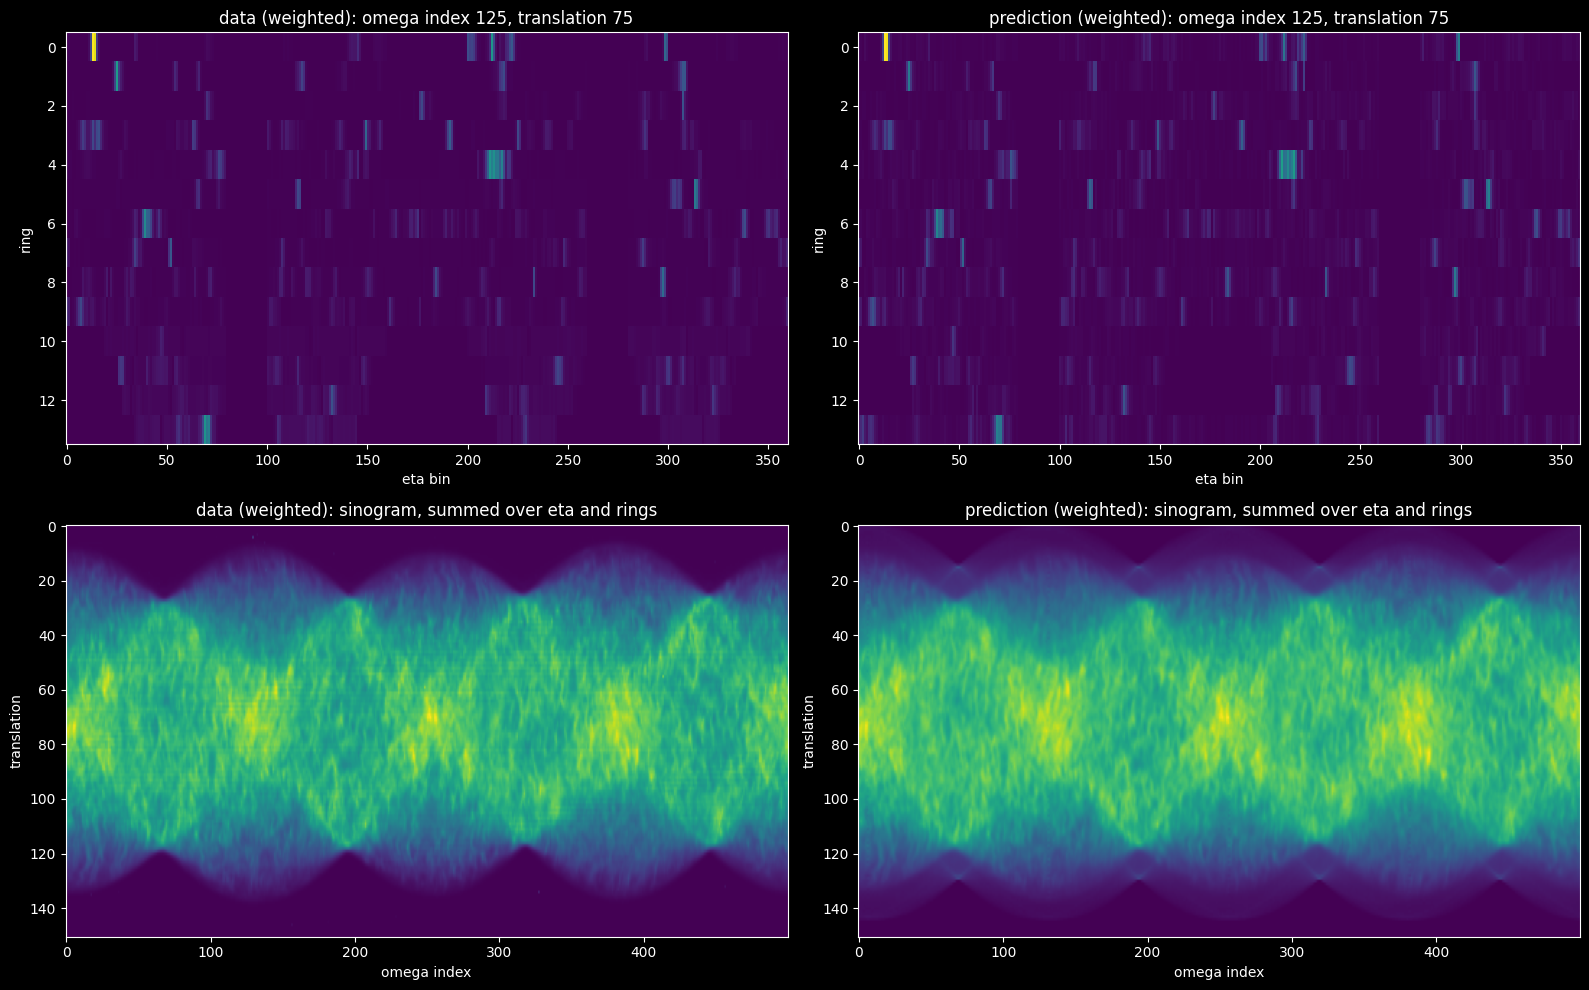

In [11]:
prediction = op.direct(x).reshape(N_Omega, My, N_eta, N_theta)

i_omega, i_trans = N_Omega // 4, My // 2
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
for col, (a, title) in enumerate([(arr * weights, "data (weighted)"), (prediction * weights, "prediction (weighted)")]):
    ax[0, col].imshow(a[i_omega, i_trans].T, aspect="auto", interpolation="nearest")
    ax[0, col].set_title(f"{title}: omega index {i_omega}, translation {i_trans}")
    ax[0, col].set_xlabel("eta bin")
    ax[0, col].set_ylabel("ring")
    ax[1, col].imshow(a.sum(axis=(2, 3)).T, aspect="auto")
    ax[1, col].set_title(f"{title}: sinogram, summed over eta and rings")
    ax[1, col].set_xlabel("omega index")
    ax[1, col].set_ylabel("translation")
plt.tight_layout()
plt.show()

## Reconstructed map
Density (sum of coefficients) and the IPF colour of the dominant orientation per voxel.

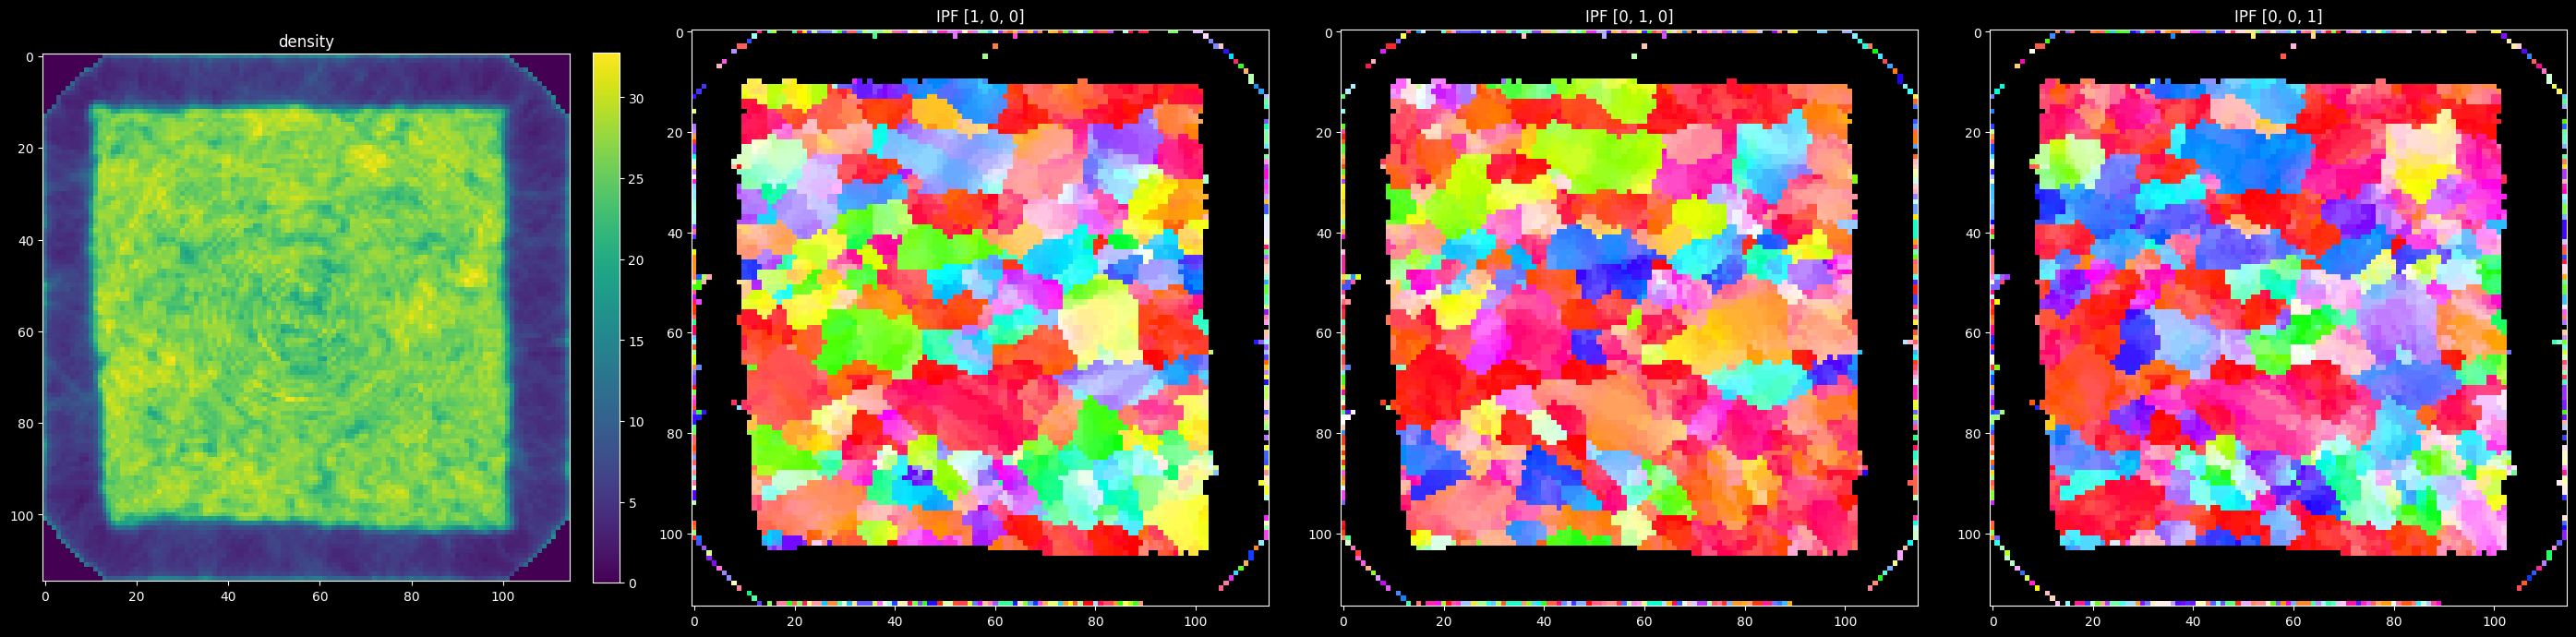

In [12]:
# per pixel, (Nx, Ny, K) with the first axis flipped: the map orientation used for the simulated data
maps = x.transpose(2, 1, 0)[::-1]
grid_mats = R.concatenate(grid.rotations_at_level(0)).as_matrix()

density = maps.sum(axis=-1)
dominant = grid_mats[np.argmax(maps, axis=-1)]
sample_mask = density > 0.3 * np.percentile(density, 99)  # display only

fig, ax = plt.subplots(1, 4, figsize=(28, 7))
im = ax[0].imshow(density)
ax[0].set_title("density")
fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
for a, direction in zip(ax[1:], ([1, 0, 0], [0, 1, 0], [0, 0, 1])):
    ipfkey = orix_plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d(direction))
    ori = Orientation.from_matrix(np.transpose(dominant.reshape(-1, 3, 3), (0, 2, 1)), symmetry.Oh)
    rgb = ipfkey.orientation2color(ori).reshape(*density.shape, 3)
    rgb[~sample_mask] = 0
    a.imshow(rgb)
    a.set_title(f"IPF {direction}")
plt.tight_layout()
plt.show()

## Save

In [13]:
out_path = os.path.join(PROCESS, "reconstruction_odf.h5")
with h5py.File(out_path, "w") as f:
    f.create_dataset("grid_mats", data=grid_mats, compression="gzip")
    ds = f.create_dataset("coeffs", data=x, compression="gzip")
    ds.attrs["axes"] = "(K, Ny, Nx)"  # coeffs[k]: the image of orientation k (rows y, columns x)
    f.attrs["data"] = OUTPUT_PATH
    f.attrs["grid"] = "odf"
    f.attrs["K"] = K
    f.attrs["sigma_deg"] = sigma_deg
    f.attrs["n_omega"] = N_Omega
    f.attrs["n_eta"] = N_eta
    f.attrs["huber_delta"] = huber_delta
    f.attrs["niter"] = niter
    f.attrs["cor_offset"] = cfg["cor_offset"]
    f.attrs["Nx"] = Nx
    f.attrs["Ny"] = Ny
    f.attrs["fista_time_s"] = fista_time
    f.attrs["odf_time_s"] = odf_time
    f.attrs["odf_spacing_deg"] = ODF_SPACING_DEG
    f.attrs["odf_levels"] = ODF_LEVELS
    f.attrs["odf_keep_mass"] = KEEP_MASS
    f.attrs["support_rel"] = SUPPORT_REL
    f.attrs["min_distance_deg"] = MIN_DISTANCE_DEG
print("saved", out_path)

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/reconstruction_odf.h5


## Sanity check: reload and plot IPF-Z

Reloads the file just saved and shows the dominant orientation per voxel as an IPF-Z map.
A quick check that the reconstruction and the save round-trip look right, not a figure for
the paper.

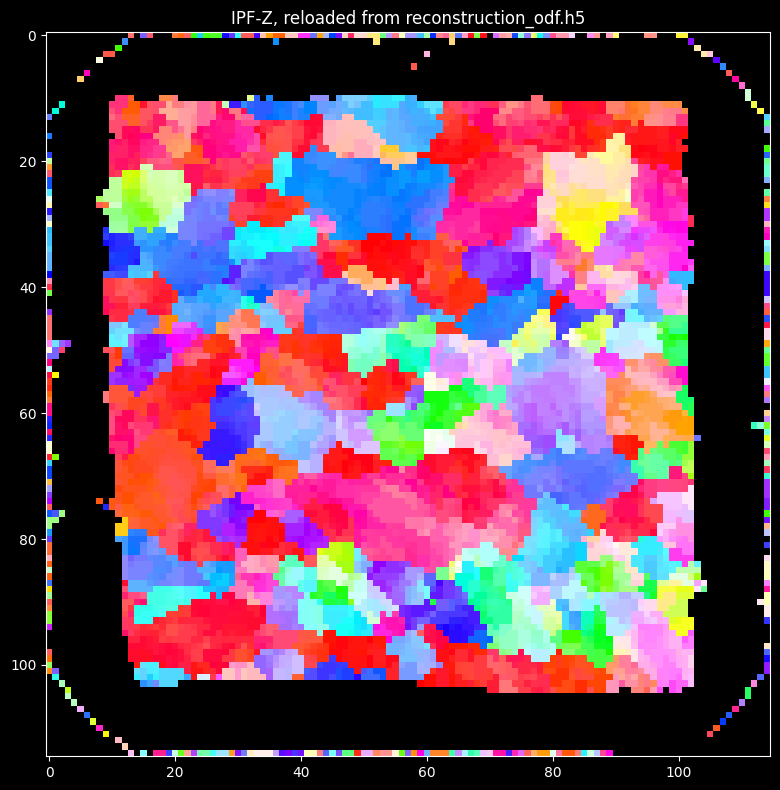

In [14]:
with h5py.File(out_path, "r") as f:
    maps_check = f["coeffs"][...].transpose(2, 1, 0)[::-1]  # per pixel, in the map orientation (as above)
    grid_mats_check = f["grid_mats"][...]

density_check = maps_check.sum(axis=-1)
dominant_check = grid_mats_check[np.argmax(maps_check, axis=-1)]
mask_check = density_check > 0.3 * np.percentile(density_check, 99)  # display only

ipfkey = orix_plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d([0, 0, 1]))
ori = Orientation.from_matrix(np.transpose(dominant_check.reshape(-1, 3, 3), (0, 2, 1)), symmetry.Oh)
rgb = ipfkey.orientation2color(ori).reshape(*density_check.shape, 3)
rgb[~mask_check] = 0

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(rgb)
ax.set_title(f"IPF-Z, reloaded from {os.path.basename(out_path)}")
plt.tight_layout()
plt.show()